# 271. Figure 1: H/P class is kept between related proteins, in runs of about 13 residues

Key sentence: *Between related proteins, the hydrophobic/polar (H/P) class of each residue
is kept well above chance, but in runs of about 13 residues.*

No kmerseek in this notebook. It draws Figure 1 of the kmerseek paper from what notebook 230
already saved, and adds two things 230 did not compute: a shuffled-partner survival curve
(230 kept only the mean of two shuffles per pair) and the k at which one chance H/P match is
expected in Swiss-Prot.

Inputs, none recomputed:

* `/Users/olga/data/pfam/230_pfam_seed_pair_class_agreement.parquet`: notebook 230's
  per-pair, per-alphabet table (kappa, longest class-identical run).
* `/Users/olga/data/pfam/230_pfam_seed_pair_alignments.parquet`: the aligned pairs it was
  computed from (`scripts/pfam_seed_pair_alignments.py`, Pfam-A 38.2 seed; the local
  `Pfam-A.seed.gz` has the MD5 of the 38.2 release, `7a37e1237d5d20c35b236c9f5a9ac797`).
* `nextflow-runs/qfo-pfam-region-benchmark/assets/kappa_by_alphabet.pfam_a_38.2_seed_pairs_20-30pct_identity.tsv`:
  kappa per alphabet with bootstrap 95% intervals over pairs, copied unchanged from commit
  `e28e8b5` (first added in `c2eaaaa`).
* `/Users/olga/data/uniprot/uniprot_sprot.2026_03.fasta.gz`: Swiss-Prot release 2026_03,
  for the residue count and H/P class shares behind k*.

Terms used in the figure:

* **Cohen's kappa**: agreement between the classes of aligned residues, corrected for
  chance: `(agree - expected) / (1 - expected)`. 0 is what a shuffle of one partner gives,
  1 is every aligned residue in the same class. Higher is better.
* **Class-identical run**: a stretch of aligned columns, with no gap, where both residues
  have the same class. For the 20-letter alphabet, same class means the same amino acid.
  The longest such run is the longest k-mer the two sequences share in that alphabet.
* **k\***: the H/P k-mer length at which one chance match is expected across all of
  Swiss-Prot, `ceil(log2(N_residues) / B)`, with `B = -log2(Pr(same class))` and
  `Pr(same class) = h^2 + p^2` for the hydrophobic share `h` and polar share `p`.

In [1]:
import gzip
import hashlib
import json
import math
import re
import sys
from pathlib import Path

import matplotlib as mpl
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle

sys.path.insert(0, str(Path.cwd()))
import hp_conservation_utils as hc

pl.Config.set_tbl_rows(40)
pl.Config.set_tbl_width_chars(200)

FIG = Path("../figures")
PAIR_TABLE = "/Users/olga/data/pfam/230_pfam_seed_pair_class_agreement.parquet"
ALIGNMENTS = "/Users/olga/data/pfam/230_pfam_seed_pair_alignments.parquet"
KAPPA_TSV = Path(
    "../nextflow-runs/qfo-pfam-region-benchmark/assets/"
    "kappa_by_alphabet.pfam_a_38.2_seed_pairs_20-30pct_identity.tsv"
)
KAPPA_TSV_SHA256 = "ecfb72b497d75b01b00d9a7e2a13acc4fac3145fe7629777b8709a7189e7acb4"
SWISSPROT = "/Users/olga/data/uniprot/uniprot_sprot.2026_03.fasta.gz"

MIN_COLS = 50  # aligned columns, the same filter notebook 230 used
BIN = "20-30%"
HP = "hp_thomas_dill2"
AA = "protein20"
HYDROPHOBIC, POLAR = hc.ALPHABET_CLUSTERS[HP]
STANDARD = "ACDEFGHIKLMNPQRSTVWY"

# Values the figure was asked to show. If the data disagree, stop instead of plotting.
EXPECTED = {"n_pairs": 37_085, "kappa_hp": 0.46, "kappa_aa": 0.20, "kstar": (28, 30)}
KS_230 = [5, 7, 10, 15, 19, 23, 26, 30]  # the k values notebook 230 tabulated
KS = list(range(1, 41))
N_SHUFFLE = 20  # shuffles of the target per pair for panel c
PANEL_A_MAX_COLS = 80  # longest alignment that fits on one line at 180 mm

# One colour per alphabet, used in every panel.
C_HP = "#B2182B"  # H/P, hp_thomas_dill2
C_AA = "#2166AC"  # the 20 amino acids, protein20
C_OTHER = "#A6A6A6"  # every other alphabet
C_HP_PALE = "#F6D2CF"  # shading of the longest class-identical run
C_KSTAR = "#333333"


def pct(x):
    """Percent with one decimal, or two significant digits below 1%, so small shares do not print as 0.0%."""
    return f"{100 * x:.1f}%" if 100 * x >= 1 else f"{100 * x:.2g}%"


def check(ok, msg):
    if not ok:
        raise AssertionError("STOP, figure not drawn: " + msg)


for fam in ("Arial", "Courier New"):
    fm.findfont(fm.FontProperties(family=fam), fallback_to_default=False)

# Nature research figures: sans-serif 5-7 pt, at most 180 mm wide, editable text in the PDF.
MONO = "Courier New"
MM = 1 / 25.4
mpl.rcParams.update(
    {
        "font.family": "Arial",
        "font.size": 6,
        "axes.labelsize": 6.5,
        "xtick.labelsize": 6,
        "ytick.labelsize": 6,
        "legend.fontsize": 6,
        "axes.linewidth": 0.5,
        "xtick.major.width": 0.5,
        "ytick.major.width": 0.5,
        "xtick.major.size": 2.5,
        "ytick.major.size": 2.5,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "svg.fonttype": "none",
    }
)

pairs = hc.add_identity_bin(pl.read_parquet(PAIR_TABLE)).filter(
    (pl.col("n_cols") >= MIN_COLS) & (pl.col("identity_bin") == BIN)
)
hp = pairs.filter(pl.col("alphabet") == HP)
aa = pairs.filter(pl.col("alphabet") == AA)
n_pairs = hp.select("family", "query", "target").unique().height
n_families = hp["family"].n_unique()
print(f"Pfam seed pairs at {BIN} identity with >= {MIN_COLS} aligned columns: {n_pairs:,} from {n_families:,} families")
check(hp.height == n_pairs and aa.height == n_pairs, "one row per pair expected")
check(n_pairs == EXPECTED["n_pairs"], f"{n_pairs:,} pairs, expected {EXPECTED['n_pairs']:,}")

Pfam seed pairs at 20-30% identity with >= 50 aligned columns: 37,085 from 15,276 families


## Panel b numbers: kappa per alphabet

Read from the kappa table, not recomputed. The 15 alphabets notebook 230 scored are checked
against the mean of its per-pair kappa; mmseqs12, wass14 and hsdm17 were added to the table
on 2026-09-21 with the same code on the same pairs (table header), so 230's per-pair table
cannot check them.

In [2]:
check(
    hashlib.sha256(KAPPA_TSV.read_bytes()).hexdigest() == KAPPA_TSV_SHA256,
    f"{KAPPA_TSV.name} is not the file copied from e28e8b5",
)
kappa = pl.read_csv(KAPPA_TSV, separator="\t", comment_prefix="#")
own = pairs.group_by("alphabet").agg(
    pl.col("kappa").mean().alias("kappa_from_230_pairs"), pl.len().alias("n_230")
)
kappa = kappa.join(own, on="alphabet", how="left").with_columns(
    (pl.col("kappa") - pl.col("kappa_from_230_pairs")).abs().alias("abs_diff")
)
print(
    kappa.select(
        "alphabet", "classes", "kappa", "kappa_lo", "kappa_hi", "n_pairs",
        pl.col("kappa_from_230_pairs").round(4), "n_230",
    ).sort("kappa", descending=True)
)
check(kappa["n_pairs"].unique().to_list() == [n_pairs], "kappa table pair count differs")
check(kappa["abs_diff"].drop_nulls().max() <= 5e-5, "kappa table disagrees with 230's pairs")
kap = {r["alphabet"]: r for r in kappa.iter_rows(named=True)}
check(round(kap[HP]["kappa"], 2) == EXPECTED["kappa_hp"], f"{HP} kappa {kap[HP]['kappa']}")
check(round(kap[AA]["kappa"], 2) == EXPECTED["kappa_aa"], f"{AA} kappa {kap[AA]['kappa']}")
print(f"\n{HP}: {kap[HP]['kappa']:.4f} [{kap[HP]['kappa_lo']:.4f}, {kap[HP]['kappa_hi']:.4f}]")
print(f"{AA}: {kap[AA]['kappa']:.4f} [{kap[AA]['kappa_lo']:.4f}, {kap[AA]['kappa_hi']:.4f}]")

shape: (18, 8)
┌──────────────────────────┬─────────┬────────┬──────────┬──────────┬─────────┬──────────────────────┬───────┐
│ alphabet                 ┆ classes ┆ kappa  ┆ kappa_lo ┆ kappa_hi ┆ n_pairs ┆ kappa_from_230_pairs ┆ n_230 │
│ ---                      ┆ ---     ┆ ---    ┆ ---      ┆ ---      ┆ ---     ┆ ---                  ┆ ---   │
│ str                      ┆ i64     ┆ f64    ┆ f64      ┆ f64      ┆ i64     ┆ f64                  ┆ u32   │
╞══════════════════════════╪═════════╪════════╪══════════╪══════════╪═════════╪══════════════════════╪═══════╡
│ hp_thomas_dill2          ┆ 2       ┆ 0.4626 ┆ 0.4616   ┆ 0.4635   ┆ 37085   ┆ 0.4626               ┆ 37085 │
│ hp_thomas_dill_no_c2     ┆ 2       ┆ 0.4541 ┆ 0.453    ┆ 0.455    ┆ 37085   ┆ 0.4541               ┆ 37085 │
│ hp_pbotc_1st_ed2         ┆ 2       ┆ 0.4389 ┆ 0.438    ┆ 0.4399   ┆ 37085   ┆ 0.4389               ┆ 37085 │
│ hp_kyte_doolittle2       ┆ 2       ┆ 0.4296 ┆ 0.4286   ┆ 0.4305   ┆ 37085   ┆ 0.4296           

## Panel a: one real pair whose longest run is the bin's median

Rule, applied in code: among the pairs in the bin whose longest H/P class-identical run
equals the median for the bin, keep those with no gap column (so the pair prints on one
line without gaps), at most 80 aligned columns, and both sequences reviewed Swiss-Prot
entries (entry names that are not accessions); then take the pair whose own kappa is
closest to the bin's mean kappa.

In [3]:
ACCESSION = re.compile(r"^([OPQ][0-9][A-Z0-9]{3}[0-9]|[A-NR-Z][0-9]([A-Z][A-Z0-9]{2}[0-9]){1,2})$")


def reviewed(seed_name):
    return ACCESSION.match(seed_name.split("/")[0].split("_")[0]) is None


median_run = hp["longest_run"].median()
check(median_run == int(median_run), f"median run {median_run} is not a whole number")
median_run = int(median_run)
mean_kappa_hp = hp["kappa"].mean()

aln = pl.read_parquet(ALIGNMENTS).select("family", "query", "target", "qaln", "taln")
cand = (
    hp.filter(pl.col("longest_run") == median_run)
    .join(aln, on=["family", "query", "target"], how="inner")
    .filter(pl.col("qaln").str.len_chars() == pl.col("n_cols"))
    .filter(pl.col("n_cols") <= PANEL_A_MAX_COLS)
    .filter(
        pl.col("query").map_elements(reviewed, return_dtype=pl.Boolean)
        & pl.col("target").map_elements(reviewed, return_dtype=pl.Boolean)
    )
    .with_columns((pl.col("kappa") - mean_kappa_hp).abs().alias("kappa_distance"))
    .sort("kappa_distance", "family", "query")
)
print(f"median longest H/P run in the bin: {median_run}; mean kappa {mean_kappa_hp:.4f}")
print(f"candidates after the rule: {cand.height}")
print(cand.select("family", "family_id", "query", "target", "n_cols", pl.col("seqid_ali").round(3), pl.col("kappa").round(3), pl.col("kappa_distance").round(3)).head(8))
pick = cand.row(0, named=True)

q, t = pick["qaln"], pick["taln"]
L = len(q)
check(set(q) <= set(STANDARD) and set(t) <= set(STANDARD), "pair has a gap or non-standard residue")
to_class = {r: ("H" if r in HYDROPHOBIC else "P") for r in STANDARD}
qc = "".join(to_class[r] for r in q)
tc = "".join(to_class[r] for r in t)
res_match = "".join("|" if a == b else " " for a, b in zip(q, t))
cls_match = "".join("|" if a == b else " " for a, b in zip(qc, tc))
n_ident = res_match.count("|")
n_same = cls_match.count("|")
runs = [(m.start(), m.end()) for m in re.finditer(r"\|+", cls_match)]
longest = max(e - s for s, e in runs)
longest_runs = [(s, e) for s, e in runs if e - s == longest]


def coords(seed_name):
    name, rng = seed_name.split("/")
    start, end = (int(x) for x in rng.split("-"))
    return name, start, end


qname, qs, qe = coords(pick["query"])
tname, ts, te = coords(pick["target"])
check(qe - qs + 1 == L and te - ts + 1 == L, "coordinates do not span the aligned residues")
check(n_ident == round(pick["seqid_ali"] * L), "identity count differs from 230's seqid_ali")
check(abs(n_same / L - pick["agree"]) < 1e-9, "class agreement differs from 230's agree")
check(longest == pick["longest_run"] == median_run, "longest run differs from 230's longest_run")

w = max(len(qname), len(tname), len("H/P class"))
print(f"\nPfam {pick['family']} ({pick['family_id']}), {L} aligned columns, no gaps\n")
print(f"{qname:<{w}} {qs:>4} {q} {qe}")
print(f"{'':<{w}} {'':>4} {res_match} {n_ident} of {L} identical")
print(f"{tname:<{w}} {ts:>4} {t} {te}")
print()
print(f"{qname:<{w}} {'':>4} {qc}")
print(f"{'':<{w}} {'':>4} {cls_match} {n_same} of {L} same class")
print(f"{tname:<{w}} {'':>4} {tc}")
print(f"{'':<{w}} {'':>4} " + "".join("^" if any(s <= i < e for s, e in longest_runs) else " " for i in range(L)) + f" longest class-identical run: {longest}")
print(f"\nH = {HYDROPHOBIC}, P = {POLAR}; pair kappa {pick['kappa']:.3f}; runs of length {longest}: {len(longest_runs)}")

median longest H/P run in the bin: 12; mean kappa 0.4626
candidates after the rule: 3
shape: (3, 8)
┌─────────┬───────────┬──────────────────┬──────────────────┬────────┬───────────┬───────┬────────────────┐
│ family  ┆ family_id ┆ query            ┆ target           ┆ n_cols ┆ seqid_ali ┆ kappa ┆ kappa_distance │
│ ---     ┆ ---       ┆ ---              ┆ ---              ┆ ---    ┆ ---       ┆ ---   ┆ ---            │
│ str     ┆ str       ┆ str              ┆ str              ┆ i64    ┆ f64       ┆ f64   ┆ f64            │
╞═════════╪═══════════╪══════════════════╪══════════════════╪════════╪═══════════╪═══════╪════════════════╡
│ PF01418 ┆ HTH_6     ┆ RPIR_ECOLI/14-90 ┆ Y143_HAEIN/5-81  ┆ 77     ┆ 0.208     ┆ 0.451 ┆ 0.012          │
│ PF01938 ┆ TRAM      ┆ YFJO_BACSU/11-68 ┆ RLMD_ECOLI/10-67 ┆ 58     ┆ 0.241     ┆ 0.488 ┆ 0.025          │
│ PF08220 ┆ HTH_DeoR  ┆ ULAR_ECOLI/6-62  ┆ AGAR_ECOLI/18-74 ┆ 57     ┆ 0.263     ┆ 0.497 ┆ 0.034          │
└─────────┴───────────┴─────────────

## Panel c: how many pairs share a class-identical run of at least k

Real pairs come from 230's per-pair `longest_run`. The shuffled curve is new: for every pair,
the target's residues are shuffled among its own residue positions (composition and gap
pattern kept, the same shuffle notebook 230 used), 20 times with a fixed seed, and the
longest H/P class-identical run is read off each shuffle. The curve is the share of pairs
reaching k, averaged over the 20 shuffles. The real runs are recomputed from the alignments
in the same loop only to check them against 230's saved values.

In [4]:
hp_aln = hp.join(aln, on=["family", "query", "target"], how="inner")
check(hp_aln.height == n_pairs, "an alignment is missing for a pair in the bin")
tab = hc.TABLES[HP]
rng = np.random.default_rng(0)
real_runs = np.empty(n_pairs, dtype=np.int64)
null_runs = np.empty((N_SHUFFLE, n_pairs), dtype=np.int64)
for i, (qa_s, ta_s) in enumerate(hp_aln.select("qaln", "taln").iter_rows()):
    qcl = tab[np.frombuffer(qa_s.encode(), dtype=np.uint8)]
    tcl = tab[np.frombuffer(ta_s.encode(), dtype=np.uint8)]
    both = (qcl != hc.GAP) & (tcl != hc.GAP)
    real_runs[i] = hc.longest_true_run((qcl == tcl) & both)
    res_idx = np.flatnonzero(tcl != hc.GAP)
    for r in range(N_SHUFFLE):
        shuffled = tcl.copy()
        shuffled[res_idx] = tcl[rng.permutation(res_idx)]
        null_runs[r, i] = hc.longest_true_run((qcl == shuffled) & both)
check(np.array_equal(real_runs, hp_aln["longest_run"].to_numpy()), "recomputed runs differ from 230's")

ks = np.array(KS)
share_hp = (real_runs[None, :] >= ks[:, None]).mean(axis=1)
share_null_each = (null_runs[:, None, :] >= ks[None, :, None]).mean(axis=2)  # shuffle x k
share_null = share_null_each.mean(axis=0)
share_aa = (aa["longest_run"].to_numpy()[None, :] >= ks[:, None]).mean(axis=1)

# Same numbers through 230's own helper, for the real pairs.
fr = hc.frac_run_at_least(pairs.filter(pl.col("alphabet").is_in([HP, AA])), ["alphabet"], KS)
for a, s in [(HP, share_hp), (AA, share_aa)]:
    ref = fr.filter(pl.col("alphabet") == a).sort("k")["frac"].to_numpy()
    check(np.allclose(ref, s), f"{a} survival curve differs from hc.frac_run_at_least")

mean_run = {"hp_real": real_runs.mean(), "hp_shuffled": null_runs.mean(), "aa_real": aa["longest_run"].mean()}
print(f"mean longest run: H/P real {mean_run['hp_real']:.2f}, H/P shuffled {mean_run['hp_shuffled']:.2f} "
      f"(230, 2 shuffles: {hp['longest_run_null'].mean():.2f}), protein20 real {mean_run['aa_real']:.2f}")
print(f"median longest run: H/P real {np.median(real_runs):.0f}, H/P shuffled {np.median(null_runs):.0f}")
surv = pl.DataFrame(
    {
        "k": KS,
        "hp_real_pct": 100 * share_hp,
        "hp_shuffled_pct": 100 * share_null,
        "hp_shuffled_min_pct": 100 * share_null_each.min(axis=0),
        "hp_shuffled_max_pct": 100 * share_null_each.max(axis=0),
        "protein20_real_pct": 100 * share_aa,
    }
)
print(surv.filter(pl.col("k").is_in(KS_230)).with_columns(pl.exclude("k").round(2)))

mean longest run: H/P real 13.01, H/P shuffled 6.33 (230, 2 shuffles: 6.33), protein20 real 3.79
median longest run: H/P real 12, H/P shuffled 6
shape: (8, 6)
┌─────┬─────────────┬─────────────────┬─────────────────────┬─────────────────────┬────────────────────┐
│ k   ┆ hp_real_pct ┆ hp_shuffled_pct ┆ hp_shuffled_min_pct ┆ hp_shuffled_max_pct ┆ protein20_real_pct │
│ --- ┆ ---         ┆ ---             ┆ ---                 ┆ ---                 ┆ ---                │
│ i64 ┆ f64         ┆ f64             ┆ f64                 ┆ f64                 ┆ f64                │
╞═════╪═════════════╪═════════════════╪═════════════════════╪═════════════════════╪════════════════════╡
│ 5   ┆ 99.87       ┆ 84.66           ┆ 84.41               ┆ 85.06               ┆ 24.5               │
│ 7   ┆ 97.2        ┆ 40.26           ┆ 39.69               ┆ 40.95               ┆ 4.87               │
│ 10  ┆ 77.62       ┆ 6.42            ┆ 6.24                ┆ 6.62                ┆ 0.52               │
│

## k\*: the H/P k at which one chance match is expected in Swiss-Prot 2026_03

Residues counted are the 20 standard amino acids, the ones that get an H/P class; other
letters (X, U, B, Z, O) are counted and reported but have no class.

In [5]:
with gzip.open(SWISSPROT, "rb") as fh:
    raw = fh.read()
n_seq = raw.count(b"\n>") + (1 if raw.startswith(b">") else 0)
seq = b"".join(line for line in raw.split(b"\n") if not line.startswith(b">"))
del raw
counts = np.bincount(np.frombuffer(seq, dtype=np.uint8), minlength=256)
del seq
n_h = int(sum(counts[ord(r)] for r in HYDROPHOBIC))
n_p = int(sum(counts[ord(r)] for r in POLAR))
n_res = n_h + n_p
n_other = int(counts.sum()) - n_res
share_h, share_p = n_h / n_res, n_p / n_res
pr_same = share_h**2 + share_p**2
bits_per_residue = -math.log2(pr_same)
kstar_exact = math.log2(n_res) / bits_per_residue
kstar = math.ceil(kstar_exact)
print(f"Swiss-Prot 2026_03: {n_seq:,} sequences, {n_res:,} residues with an H/P class, {n_other:,} other letters")
print(f"hydrophobic share h = {share_h:.4f}, polar share p = {share_p:.4f}, Pr(same class) = {pr_same:.4f}")
print(f"B = -log2(Pr(same class)) = {bits_per_residue:.4f} bits; log2(N) = {math.log2(n_res):.3f}")
print(f"k* = ceil({math.log2(n_res):.3f} / {bits_per_residue:.4f}) = ceil({kstar_exact:.2f}) = {kstar}")
check(EXPECTED["kstar"][0] <= kstar <= EXPECTED["kstar"][1], f"k* = {kstar}, expected 28-30")
print(f"pairs at {BIN} reaching k*: H/P real {100 * share_hp[kstar - 1]:.2f}%, shuffled {100 * share_null[kstar - 1]:.3f}%")

Swiss-Prot 2026_03: 575,748 sequences, 209,008,777 residues with an H/P class, 9,066 other letters
hydrophobic share h = 0.4236, polar share p = 0.5764, Pr(same class) = 0.5117
B = -log2(Pr(same class)) = 0.9667 bits; log2(N) = 27.639
k* = ceil(27.639 / 0.9667) = ceil(28.59) = 29
pairs at 20-30% reaching k*: H/P real 0.82%, shuffled 0.000%


## Figure 1

180 mm wide (Nature two-column width), Arial 5-7 pt, Courier New for sequences, text kept
editable in the PDF (TrueType). Red is H/P (hp_thomas_dill2) and blue is the 20 amino acids
(protein20) in every panel.

panel b, one dot per alphabet:
shape: (18, 6)
┌─────┬──────────────────────────┬─────────┬────────┬──────────┬──────────┐
│ y   ┆ alphabet                 ┆ classes ┆ kappa  ┆ kappa_lo ┆ kappa_hi │
│ --- ┆ ---                      ┆ ---     ┆ ---    ┆ ---      ┆ ---      │
│ i64 ┆ str                      ┆ i64     ┆ f64    ┆ f64      ┆ f64      │
╞═════╪══════════════════════════╪═════════╪════════╪══════════╪══════════╡
│ 1   ┆ hp_thomas_dill2          ┆ 2       ┆ 0.4626 ┆ 0.4616   ┆ 0.4635   │
│ 2   ┆ hp_thomas_dill_no_c2     ┆ 2       ┆ 0.4541 ┆ 0.453    ┆ 0.455    │
│ 3   ┆ hp_pbotc_1st_ed2         ┆ 2       ┆ 0.4389 ┆ 0.438    ┆ 0.4399   │
│ 4   ┆ hp_kyte_doolittle2       ┆ 2       ┆ 0.4296 ┆ 0.4286   ┆ 0.4305   │
│ 5   ┆ hp_lehninger_c_nonpolar2 ┆ 2       ┆ 0.4014 ┆ 0.4004   ┆ 0.4024   │
│ 6   ┆ hp_lehninger_hpc3        ┆ 3       ┆ 0.397  ┆ 0.396    ┆ 0.398    │
│ 7   ┆ hp_lehninger2            ┆ 2       ┆ 0.3944 ┆ 0.3934   ┆ 0.3954   │
│ 9   ┆ gbmr4                    ┆ 4      

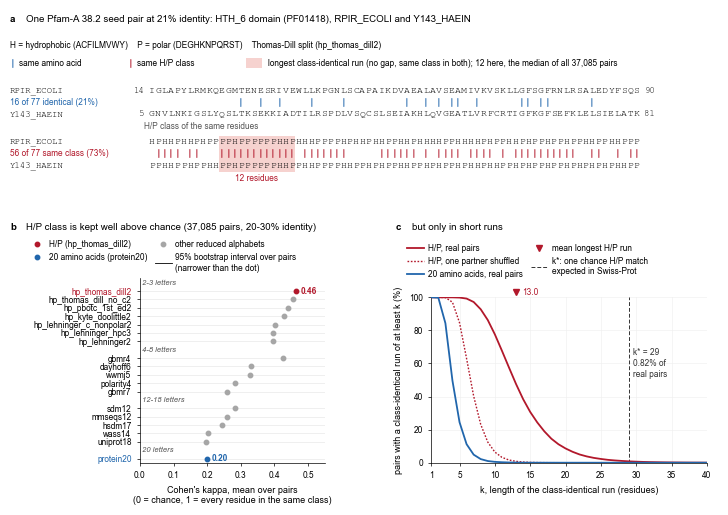

In [6]:
FIG_W, FIG_H = 180, 132  # mm
fig = plt.figure(figsize=(FIG_W * MM, FIG_H * MM))


def axes_mm(x, y, w, h):
    return fig.add_axes([x / FIG_W, y / FIG_H, w / FIG_W, h / FIG_H])


def panel_letter(x, y, letter, title):
    fig.text(x / FIG_W, y / FIG_H, letter, fontsize=7, fontweight="bold", va="baseline")
    fig.text((x + 4) / FIG_W, y / FIG_H, title, fontsize=7, va="baseline")


# ---- a: the pair -----------------------------------------------------------------------
ax = axes_mm(0, 78, FIG_W, 50)
ax.set_xlim(0, FIG_W)
ax.set_ylim(0, 50)
ax.axis("off")
panel_letter(0, 125, "a", f"One Pfam-A 38.2 seed pair at {100 * pick['seqid_ali']:.0f}% identity: "
             f"{pick['family_id']} domain ({pick['family']}), {qname} and {tname}")
X0, COLW = 36.0, 1.62  # mm: first column, column spacing
check(X0 + (L + 3) * COLW <= FIG_W, f"{L} columns do not fit in {FIG_W} mm")
xcol = lambda i: X0 + i * COLW
x_end = xcol(L - 1)
# Legend, above the alignment.
ax.text(0, 41, f"H = hydrophobic ({HYDROPHOBIC})    P = polar ({POLAR})    Thomas-Dill split (hp_thomas_dill2)", fontsize=6, va="center")
lx = 0
for mark, color, label in [("|", C_AA, "same amino acid"), ("|", C_HP, "same H/P class")]:
    ax.text(lx, 36.5, mark, family=MONO, fontsize=7, color=color, va="center", fontweight="bold")
    ax.text(lx + 2.2, 36.5, label, fontsize=6, va="center")
    lx += 30
ax.add_patch(Rectangle((lx, 35.2), 4, 2.6, facecolor=C_HP_PALE, edgecolor="none"))
ax.text(lx + 5.5, 36.5, f"longest class-identical run (no gap, same class in both); {longest} here, the median of all {n_pairs:,} pairs",
        fontsize=6, va="center")


def draw_row(y, chars, color="black", weight="normal"):
    for i, ch in enumerate(chars):
        if ch != " ":
            ax.text(xcol(i), y, ch, family=MONO, fontsize=7, color=color, ha="center", va="center", fontweight=weight)


ROW = {"q": 29.5, "rm": 26.5, "t": 23.5, "qc": 16.5, "cm": 13.5, "tc": 10.5}
for s, e in longest_runs:
    ax.add_patch(Rectangle((xcol(s) - COLW / 2, ROW["tc"] - 1.6), (e - s) * COLW, ROW["qc"] - ROW["tc"] + 3.2,
                           facecolor=C_HP_PALE, edgecolor="none", zorder=0))
for key, chars, name, start, end in [("q", q, qname, qs, qe), ("t", t, tname, ts, te)]:
    ax.text(0, ROW[key], name, family=MONO, fontsize=6.5, va="center")
    ax.text(X0 - 2.0, ROW[key], str(start), family=MONO, fontsize=6.5, va="center", ha="right")
    ax.text(x_end + 2.0, ROW[key], str(end), family=MONO, fontsize=6.5, va="center")
    draw_row(ROW[key], chars)
for key, chars, name in [("qc", qc, qname), ("tc", tc, tname)]:
    ax.text(0, ROW[key], name, family=MONO, fontsize=6.5, va="center")
    draw_row(ROW[key], chars)
draw_row(ROW["rm"], res_match, C_AA, "bold")
draw_row(ROW["cm"], cls_match, C_HP, "bold")
# Counts sit in the label column, on the match line they count.
ax.text(0, ROW["rm"], f"{n_ident} of {L} identical ({100 * n_ident / L:.0f}%)", fontsize=6, va="center", color=C_AA)
ax.text(0, ROW["cm"], f"{n_same} of {L} same class ({100 * n_same / L:.0f}%)", fontsize=6, va="center", color=C_HP)
for s_, e_ in longest_runs:
    ax.text((xcol(s_) + xcol(e_ - 1)) / 2, ROW["tc"] - 3.2, f"{e_ - s_} residues", fontsize=6, ha="center", va="center", color=C_HP)
ax.text(X0 - 2.0, ROW["qc"] + 4.0, "H/P class of the same residues", fontsize=6, va="center", ha="left", color="#555555",
        transform=ax.transData)

# ---- b: kappa per alphabet ---------------------------------------------------------------
c = pl.col("classes")
GROUPS = [("2-3 letters", c <= 3), ("4-8 letters", c.is_between(4, 8)),
          ("12-18 letters", c.is_between(12, 18)), ("20 letters", c == 20)]
kb = kappa.sort("kappa", descending=True)
ypos, labels, rows_b, group_y = [], [], [], []
y = 0
for gname, member in GROUPS:
    g = kb.filter(member)
    group_y.append((y, gname))
    y += 1
    for r in g.iter_rows(named=True):
        rows_b.append((y, r))
        y += 1
y_max = y
axb = axes_mm(33, 13, 47, 47)
for yy, r in rows_b:
    color = C_HP if r["alphabet"] == HP else C_AA if r["alphabet"] == AA else C_OTHER
    axb.errorbar(r["kappa"], yy, xerr=[[r["kappa"] - r["kappa_lo"]], [r["kappa_hi"] - r["kappa"]]],
                 fmt="o", ms=3.2, color=color, ecolor="black", elinewidth=0.6, capsize=0, zorder=3)
    if r["alphabet"] in (HP, AA):
        axb.text(r["kappa"] + 0.015, yy, f"{r['kappa']:.2f}", color=color, fontsize=6, va="center", fontweight="bold")
for gy, gname in group_y:
    axb.text(0.005, gy, gname, fontsize=5.5, style="italic", color="#555555", va="center")
axb.set_yticks([yy for yy, _ in rows_b], [r["alphabet"] for _, r in rows_b])
for lab, (_, r) in zip(axb.get_yticklabels(), rows_b):
    lab.set_color(C_HP if r["alphabet"] == HP else C_AA if r["alphabet"] == AA else "black")
axb.set_ylim(y_max - 0.5, -0.6)
axb.set_xlim(0, 0.55)
axb.set_xticks([0, 0.1, 0.2, 0.3, 0.4, 0.5])
axb.grid(axis="y", color="#E3E3E3", lw=0.4)
axb.set_axisbelow(True)
axb.set_xlabel("Cohen's kappa, mean over pairs\n(0 = chance, 1 = every residue in the same class)")
handles_b = [
    Line2D([], [], marker="o", ls="", ms=3.2, color=C_HP, label="H/P (hp_thomas_dill2)"),
    Line2D([], [], marker="o", ls="", ms=3.2, color=C_AA, label="20 amino acids (protein20)"),
    Line2D([], [], marker="o", ls="", ms=3.2, color=C_OTHER, label="other reduced alphabets"),
    Line2D([], [], color="black", lw=0.6, label="95% bootstrap interval over pairs\n(narrower than the dot)"),
]
axb.legend(handles=handles_b, loc="lower left", bbox_to_anchor=(-0.62, 1.01), frameon=False, ncol=2,
           handletextpad=0.4, columnspacing=1.0, borderaxespad=0)
panel_letter(0, 72, "b", f"H/P class is kept well above chance ({n_pairs:,} pairs, {BIN} identity)")

# ---- c: share of pairs with a class-identical run of at least k --------------------------
axc = axes_mm(107, 13, 70, 42)
axc.plot(KS, 100 * share_null, color=C_HP, lw=1.0, ls=(0, (1.2, 1.2)), zorder=2)
axc.plot(KS, 100 * share_hp, color=C_HP, lw=1.3, zorder=3)
axc.plot(KS, 100 * share_aa, color=C_AA, lw=1.3, zorder=3)
axc.axvline(kstar, color=C_KSTAR, lw=0.7, ls=(0, (4, 2)), zorder=1)
axc.plot([mean_run["hp_real"]], [103], marker="v", ms=4, color=C_HP, clip_on=False, zorder=4)
axc.text(mean_run["hp_real"] + 0.8, 103, f"{mean_run['hp_real']:.1f}", color=C_HP, fontsize=6, va="center")
axc.text(kstar + 0.6, 60, f"k* = {kstar}\n{pct(share_hp[kstar - 1])} of\nreal pairs", fontsize=6, va="center",
         color=C_KSTAR, linespacing=1.25)
axc.set_xlim(1, 40)
axc.set_ylim(0, 100)
axc.set_xticks([1, 5, 10, 15, 20, 25, 30, 35, 40])
axc.set_xlabel("k, length of the class-identical run (residues)")
axc.set_ylabel("pairs with a class-identical run of at least k (%)")
axc.grid(color="#EEEEEE", lw=0.4)
axc.set_axisbelow(True)
handles_c = [
    Line2D([], [], color=C_HP, lw=1.3, label="H/P, real pairs"),
    Line2D([], [], color=C_HP, lw=1.0, ls=(0, (1.2, 1.2)), label="H/P, one partner shuffled"),
    Line2D([], [], color=C_AA, lw=1.3, label="20 amino acids, real pairs"),
    Line2D([], [], marker="v", ls="", ms=4, color=C_HP, label="mean longest H/P run"),
    Line2D([], [], color=C_KSTAR, lw=0.7, ls=(0, (4, 2)),
           label="k*: one chance H/P match\nexpected in Swiss-Prot"),
]
axc.legend(handles=handles_c, loc="lower left", bbox_to_anchor=(-0.1, 1.09), frameon=False, ncol=2,
           handletextpad=0.5, columnspacing=1.0, borderaxespad=0)
panel_letter(98, 72, "c", "but only in short runs")

FIG.mkdir(exist_ok=True)
fig.savefig(FIG / "fig1_hp_runs.pdf")
fig.savefig(FIG / "fig1_hp_runs.png", dpi=300)

print("panel b, one dot per alphabet:")
print(pl.DataFrame([{"y": yy, **{k: r[k] for k in ("alphabet", "classes", "kappa", "kappa_lo", "kappa_hi")}} for yy, r in rows_b]))
print("panel c, curves at every k drawn:")
print(surv.with_columns(pl.exclude("k").round(2)))

## Caption and the values behind it

Every number in the caption is formatted from a variable computed above. The same values
are saved to `figures/fig1_hp_runs_values.json` so each one can be traced.

In [7]:
at = lambda arr, k: arr[k - 1]
values = {
    "pfam_release": "Pfam-A 38.2 seed",
    "identity_bin": BIN,
    "min_aligned_columns": MIN_COLS,
    "n_pairs": n_pairs,
    "n_families": n_families,
    "panel_a": {
        "family": pick["family"], "family_id": pick["family_id"],
        "query": pick["query"], "target": pick["target"],
        "aligned_columns": L, "identical": n_ident, "same_class": n_same,
        "identity": pick["seqid_ali"], "pair_kappa": pick["kappa"],
        "longest_class_identical_run": longest, "bin_median_longest_run": median_run,
        "n_candidates_after_rule": cand.height,
    },
    "panel_b": {a: {k: kap[a][k] for k in ("classes", "kappa", "kappa_lo", "kappa_hi", "n_pairs")} for a in kap},
    "panel_c": {
        "n_shuffles": N_SHUFFLE,
        "mean_longest_run": mean_run,
        "median_longest_run_hp_real": float(np.median(real_runs)),
        "share_at_k": {int(k): {"hp_real": float(at(share_hp, k)), "hp_shuffled": float(at(share_null, k)),
                                "protein20_real": float(at(share_aa, k))} for k in KS},
    },
    "kstar": {
        "swissprot": "2026_03", "n_sequences": n_seq, "n_residues_with_class": n_res,
        "n_other_letters": n_other, "share_hydrophobic": share_h, "share_polar": share_p,
        "pr_same_class": pr_same, "bits_per_residue": bits_per_residue,
        "kstar_exact": kstar_exact, "kstar": kstar,
    },
}
(FIG / "fig1_hp_runs_values.json").write_text(json.dumps(values, indent=1, default=float))

others = [r for a, r in kap.items() if a not in (HP, AA)]
caption = f"""**Figure 1 | Between related proteins, the hydrophobic/polar (H/P) class of each residue is kept well above chance, but in runs of about {mean_run['hp_real']:.0f} residues.**
All panels use pairs of sequences from the same Pfam-A 38.2 seed alignment with {BIN.replace('-', '–')} identity over at least {MIN_COLS} aligned columns ({n_pairs:,} pairs from {n_families:,} families). H/P is the Thomas–Dill split: hydrophobic {HYDROPHOBIC}, polar {POLAR}. Red marks H/P and blue the 20 amino acids in every panel.
**a**, One of these pairs, {qname} residues {qs}–{qe} and {tname} residues {ts}–{te} ({pick['family_id']}, {pick['family']}), chosen because its longest class-identical run ({longest} residues: aligned columns in a row, no gap, same class in both) equals the median of all {n_pairs:,} pairs. Over {L} aligned columns, {n_ident} residues are identical ({100 * n_ident / L:.0f}%) and {n_same} have the same H/P class ({100 * n_same / L:.0f}%).
**b**, Cohen's kappa (agreement beyond chance; 0 is what shuffling one partner gives, 1 is every residue in the same class), the mean of per-pair kappa with 95% bootstrap intervals over pairs. H/P: {kap[HP]['kappa']:.4f} ({kap[HP]['kappa_lo']:.4f}–{kap[HP]['kappa_hi']:.4f}); 20 amino acids: {kap[AA]['kappa']:.4f} ({kap[AA]['kappa_lo']:.4f}–{kap[AA]['kappa_hi']:.4f}); the other {len(others)} alphabets {min(r['kappa'] for r in others):.2f}–{max(r['kappa'] for r in others):.2f}.
**c**, Share of pairs whose longest class-identical run is at least k. The mean longest H/P run is {mean_run['hp_real']:.1f} residues in real pairs (median {np.median(real_runs):.0f}) and {mean_run['hp_shuffled']:.1f} when one partner's residues are shuffled ({N_SHUFFLE} shuffles per pair, composition and gaps kept); for the 20 amino acids it is {mean_run['aa_real']:.1f}. At k = 19, {pct(at(share_hp, 19))} of real pairs share an H/P run ({pct(at(share_null, 19))} shuffled); at k = 26, {pct(at(share_hp, 26))}. Dashed line: k* = {kstar}, the H/P k-mer length at which one chance match is expected across Swiss-Prot 2026_03 ({n_res:,} residues; hydrophobic share {share_h:.3f}; k* = ⌈log2 N / B⌉ with B = −log2(h² + p²) = {bits_per_residue:.3f} bits per residue). {pct(at(share_hp, kstar))} of real pairs reach k*.
"""
(FIG / "fig1_hp_runs_caption.md").write_text(caption)
print(caption)
print(f"caption words: {len(re.sub(r'[*]', '', caption).split())}")

**Figure 1 | Between related proteins, the hydrophobic/polar (H/P) class of each residue is kept well above chance, but in runs of about 13 residues.**
All panels use pairs of sequences from the same Pfam-A 38.2 seed alignment with 20–30% identity over at least 50 aligned columns (37,085 pairs from 15,276 families). H/P is the Thomas–Dill split: hydrophobic ACFILMVWY, polar DEGHKNPQRST. Red marks H/P and blue the 20 amino acids in every panel.
**a**, One of these pairs, RPIR_ECOLI residues 14–90 and Y143_HAEIN residues 5–81 (HTH_6, PF01418), chosen because its longest class-identical run (12 residues: aligned columns in a row, no gap, same class in both) equals the median of all 37,085 pairs. Over 77 aligned columns, 16 residues are identical (21%) and 56 have the same H/P class (73%).
**b**, Cohen's kappa (agreement beyond chance; 0 is what shuffling one partner gives, 1 is every residue in the same class), the mean of per-pair kappa with 95% bootstrap intervals over pairs. H/P: 0.462

## Summary and conclusions

The numbers are printed by the cells above and written to `figures/fig1_hp_runs_values.json`;
the caption in `figures/fig1_hp_runs_caption.md` is formatted from the same variables.

1. In Pfam seed pairs at 20-30% identity, the H/P class of aligned residues agrees well
   beyond chance (kappa 0.46, where 0 is chance and higher means more of the class pattern
   is kept), more than twice the agreement of the residues themselves (protein20 kappa 0.20).
2. That agreement comes in short stretches. The longest class-identical H/P run averages
   13.0 residues in real pairs (median 12) and 6.3 when one partner is shuffled.
3. An exact H/P k-mer needs a class-identical run of length k. At k\* = 29, the length at
   which one chance match is expected in Swiss-Prot 2026_03, 0.82% of these pairs share a
   run that long; at k = 19, 11.2% do. Exact H/P k-mers long enough to stand out of
   Swiss-Prot reach almost none of the pairs whose H/P pattern is clearly kept.